In [1]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import os

### 1. Data collection 

In [2]:
name =  "eiffel_tower"
lat = 48.8584
lon = 2.2945

radius = 1000  

<Axes: >

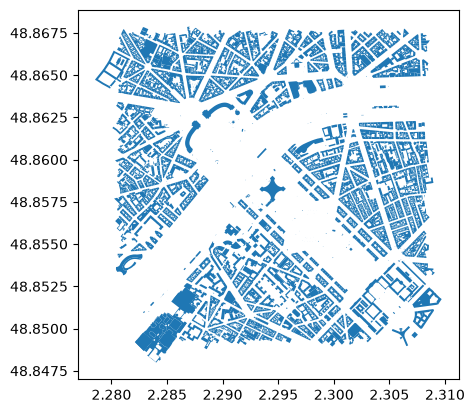

In [3]:
buildings = ox.features_from_point(
    center_point=(lat, lon),
    tags={"building": True},
    dist=radius
)
buildings = buildings[buildings.geom_type.isin(["Polygon", "MultiPolygon"])]
buildings.plot()

<Axes: >

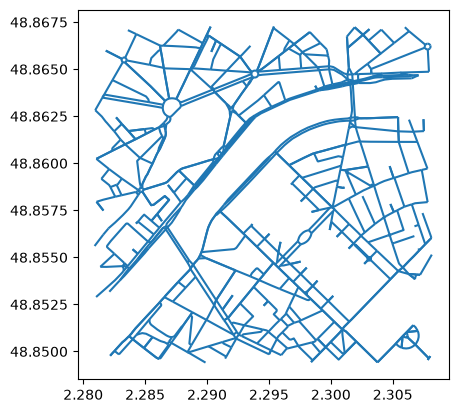

In [4]:
G = ox.graph_from_point(
    center_point=(lat, lon),
    dist=radius,
    network_type="drive"
)
roads = ox.graph_to_gdfs(G, nodes=False, edges=True)

roads.plot()

<Axes: >

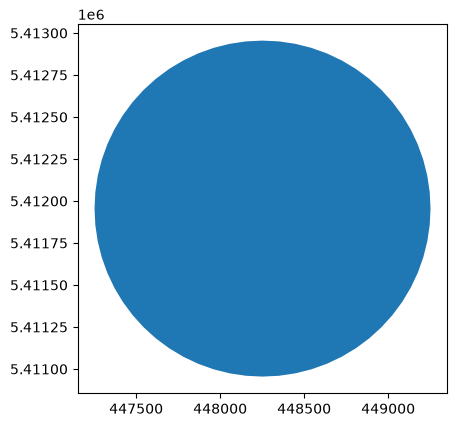

In [5]:
# Build center point in WGS84
center = gpd.GeoSeries([Point(lon, lat)], crs="EPSG:4326")

# Compute a local UTM CRS automatically
utm_crs = center.estimate_utm_crs()

# Buffer circle in UTM meters
circle_utm = center.to_crs(utm_crs).buffer(radius)
circle = gpd.GeoDataFrame(geometry=circle_utm, crs=utm_crs)

circle.plot()

<Axes: >

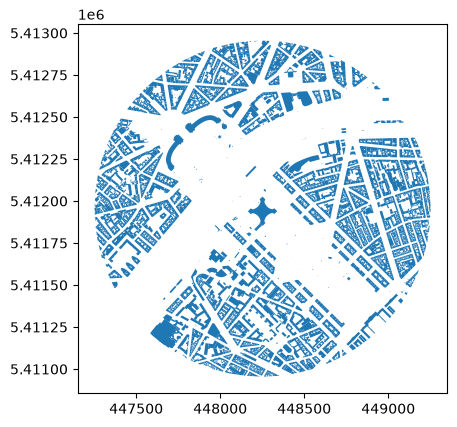

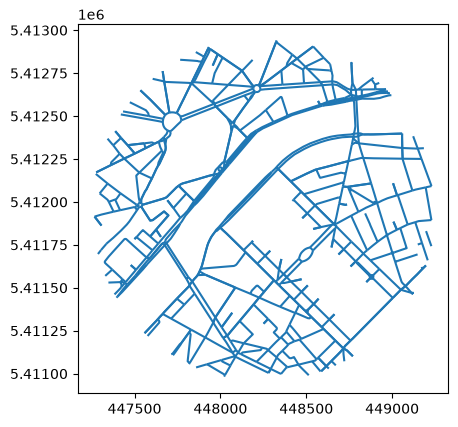

In [6]:
buildings_clipped = gpd.clip(buildings.to_crs(utm_crs), circle)
roads_clipped = gpd.clip(roads.to_crs(utm_crs), circle)

buildings_clipped.plot()
roads_clipped.plot()

### 2. Data collection

In [7]:
landmarks = {
    "eiffel_tower": (48.8584, 2.2945),
    "giza_pyramids": (29.9792, 31.1342),
    "colosseum_rome": (41.8902, 12.4922),
    "central_park": (40.7829, -73.9654),
    "budapest_parliament": (47.5070, 19.0459),
    "sagrada_familia": (41.4036, 2.1744),
    "brandenburg_gate": (52.5163, 13.3777)
}

landmarks_gdf = gpd.GeoDataFrame(
    {
        "name": list(landmarks.keys()),
        "lat": [landmarks[k][0] for k in landmarks],
        "lon": [landmarks[k][1] for k in landmarks]
    },
    geometry=[Point(lon, lat) for (lat, lon) in landmarks.values()],
    crs="EPSG:4326"
)

landmarks_gdf

,name,lat,lon,geometry
0,eiffel_tower,48.8584,2.2945,POINT (2.2945 48.8584)
1,giza_pyramids,29.9792,31.1342,POINT (31.1342 29.9792)
2,colosseum_rome,41.8902,12.4922,POINT (12.4922 41.8902)
3,central_park,40.7829,-73.9654,POINT (-73.9654 40.7829)
4,budapest_parliament,47.5070,19.0459,POINT (19.0459 47.507)
5,sagrada_familia,41.4036,2.1744,POINT (2.1744 41.4036)
6,brandenburg_gate,52.5163,13.3777,POINT (13.3777 52.5163)


In [8]:

results = {}

for name, (lat, lon) in landmarks.items():
    print(f"\nProcessing {name}...")

    # ---------------------------
    # 1. GET BUILDINGS (your working method)
    # ---------------------------
    buildings = ox.features_from_point(
        center_point=(lat, lon),
        tags={"building": True},
        dist=radius
    )
    buildings = buildings[buildings.geom_type.isin(["Polygon", "MultiPolygon"])]


    # ---------------------------
    # 2. GET ROADS
    # ---------------------------
    G = ox.graph_from_point(
        center_point=(lat, lon),
        dist=radius,
        network_type="drive"
    )
    roads = ox.graph_to_gdfs(G, nodes=False, edges=True)


    # ---------------------------
    # 3. CREATE ACCURATE 500 m CIRCLE
    # ---------------------------
    # Build center point in WGS84


    center = gpd.GeoSeries([Point(lon, lat)], crs="EPSG:4326")

    # Compute a local UTM CRS automatically
    utm_crs = center.estimate_utm_crs()

    # Buffer circle in UTM meters
    circle_utm = center.to_crs(utm_crs).buffer(radius)
    circle = gpd.GeoDataFrame(geometry=circle_utm, crs=utm_crs)

    # ---------------------------
    # 4. CLIP BUILDINGS + ROADS PRECISELY TO THE CIRCLE
    # ---------------------------
    buildings_clipped = gpd.clip(buildings.to_crs(utm_crs), circle)
    roads_clipped = gpd.clip(roads.to_crs(utm_crs), circle)

    results[name] = {
        "buildings": buildings_clipped.to_crs(4326),
        "roads": roads_clipped.to_crs(4326),
        "circle": circle.to_crs(4326)
    }


    



Processing eiffel_tower...

Processing giza_pyramids...

Processing colosseum_rome...

Processing central_park...

Processing budapest_parliament...

Processing sagrada_familia...

Processing brandenburg_gate...


### 3. Maps

In [9]:
BACKGROUND = "#34495E"   # dark blue
FOREGROUND = "#F0F1F2"   # off-white
HIGHLIGHT = "#F4D03F"    # golden yellow

name = "eiffel_tower"
buildings = results[name]["buildings"]
roads = results[name]["roads"]
circle = results[name]["circle"]
target_building = gpd.sjoin(buildings, landmarks_gdf[landmarks_gdf.name==name])

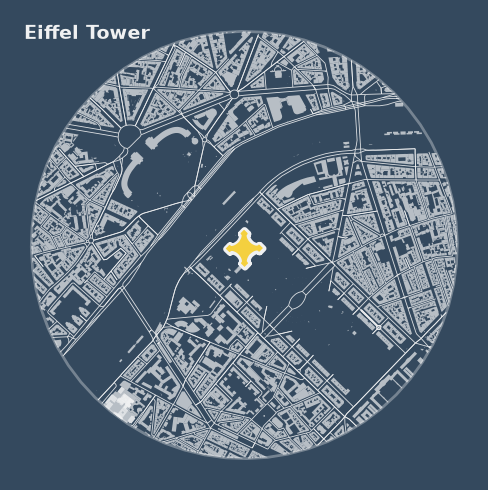

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.set_facecolor(BACKGROUND)
fig.patch.set_facecolor(BACKGROUND)

roads.plot(ax=ax, linewidth=0.6, color=FOREGROUND, alpha=0.9)
buildings.plot(ax=ax, linewidth=1.0, color=FOREGROUND, alpha=0.7)
target_building.plot(ax=ax, edgecolor=FOREGROUND, linewidth=4.5, alpha=1.0)
target_building.plot(ax=ax, color=HIGHLIGHT, linewidth=1.5, alpha=1.0)

circle.boundary.plot(ax=ax, linewidth=2, color=FOREGROUND, alpha=0.35)


ax.text(
    0.03,              
    0.97,              
    name.replace("_", " ").title(), 
    transform=ax.transAxes,
    ha="left",
    va="top",
    color=FOREGROUND,
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

Saved: maps_output/eiffel_tower.png
Saved: maps_output/giza_pyramids.png
Saved: maps_output/colosseum_rome.png
Saved: maps_output/central_park.png
Saved: maps_output/budapest_parliament.png
Saved: maps_output/sagrada_familia.png
Saved: maps_output/brandenburg_gate.png


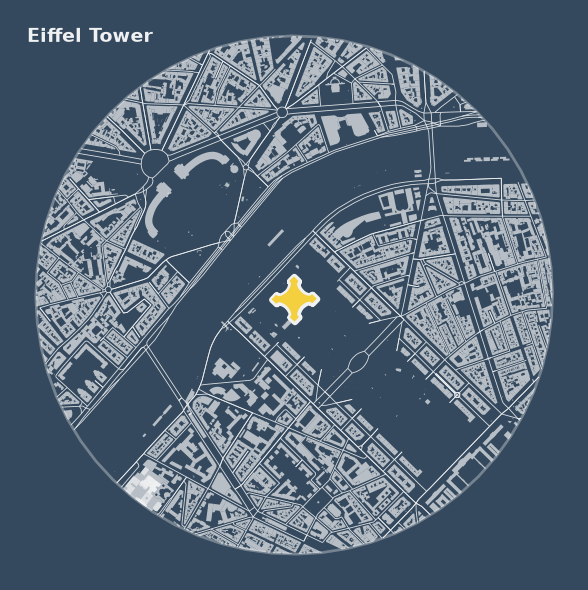

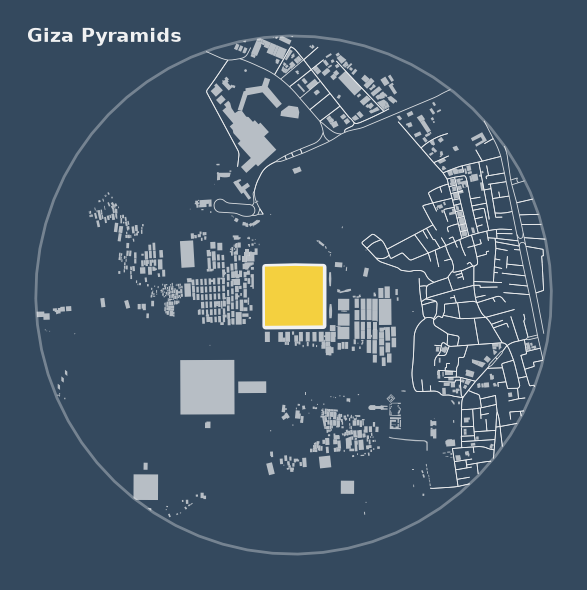

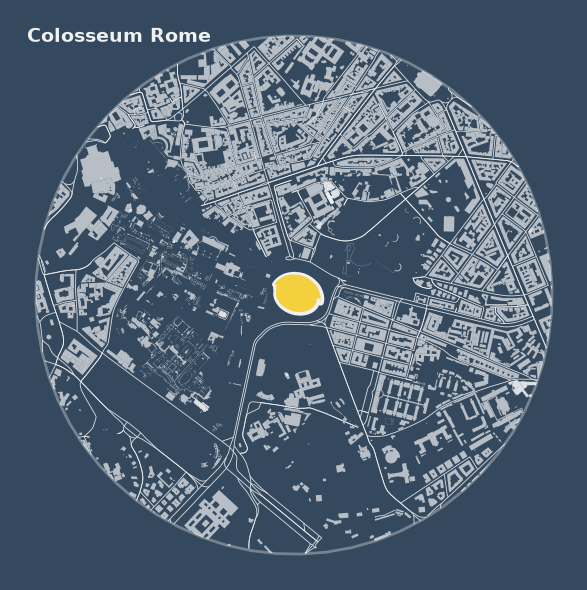

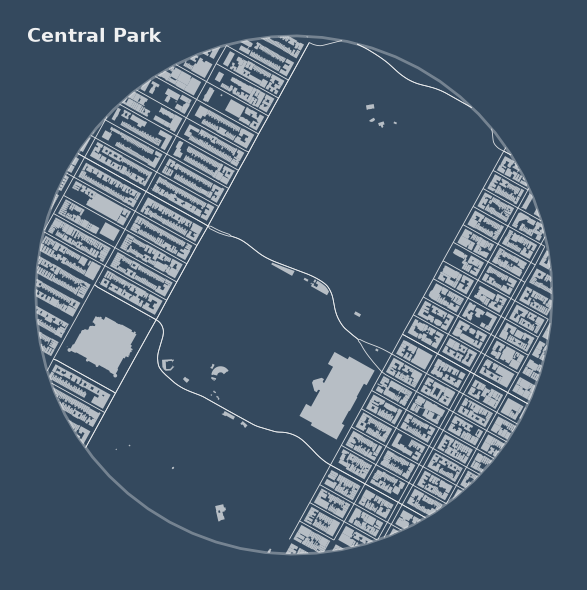

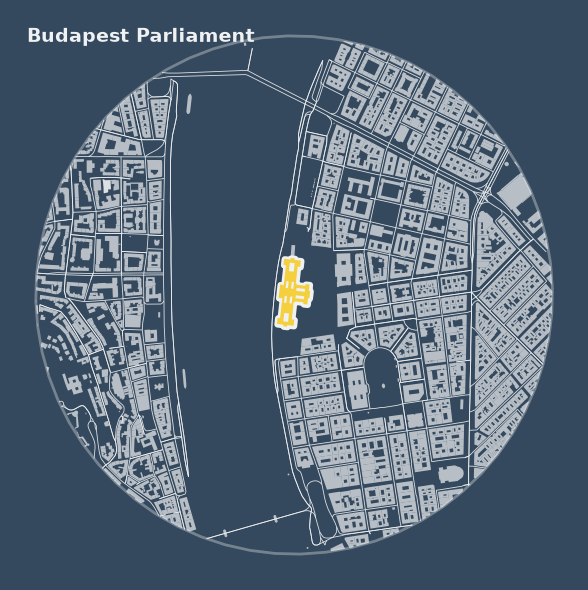

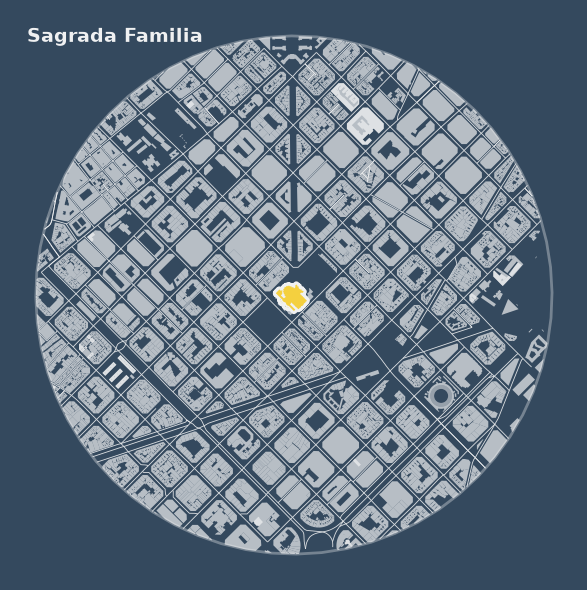

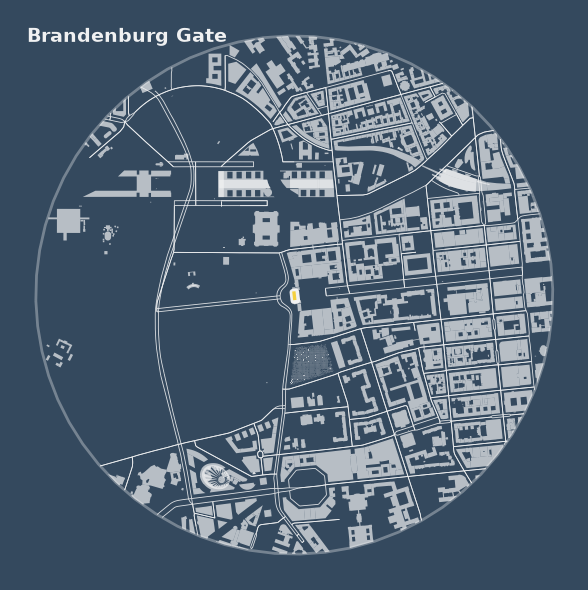

In [11]:
os.makedirs("maps_output", exist_ok=True)

def plot_landmark(name, results, save_folder="maps_output"):
    
    buildings = results[name]["buildings"]
    roads = results[name]["roads"]
    circle = results[name]["circle"]
    target_building = gpd.sjoin(buildings, landmarks_gdf[landmarks_gdf.name==name])

    fig, ax = plt.subplots(figsize=(6, 6))

    # Background
    ax.set_facecolor(BACKGROUND)
    fig.patch.set_facecolor(BACKGROUND)

    # Roads
    roads.plot(ax=ax, linewidth=0.6, color=FOREGROUND, alpha=0.9)

    # Buildings
    buildings.plot(ax=ax, linewidth=1.0, color=FOREGROUND, alpha=0.7)

    # Circle boundary
    circle.boundary.plot(ax=ax, linewidth=2, color=FOREGROUND, alpha=0.35)

    if name != 'central_park':
        target_building.plot(ax=ax, edgecolor=FOREGROUND, linewidth=4.5, alpha=1.0)
        target_building.plot(ax=ax, color=HIGHLIGHT, linewidth=1.5, alpha=1.0)

    
    # Title top-left
    ax.text(
        0.03, 0.97,
        name.replace("_", " ").title(),
        transform=ax.transAxes,
        ha="left", va="top",
        color=FOREGROUND, fontsize=14, fontweight="bold"
    )

    ax.set_axis_off()
    plt.tight_layout()

    # save
    filename = f"{save_folder}/{name}.png"
    plt.savefig(filename, dpi=300, facecolor=BACKGROUND, bbox_inches="tight", pad_inches=0.1)
    #plt.close()

    print(f"Saved: {filename}")


for lm in results.keys():
    plot_landmark(lm, results)
